# 🚀 Machine Learning Project – Predicting Customer Purchase Behavior

## Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## loading dataset and inspection

In [2]:
df = pd.read_csv("shop_smart_ecommerce.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [6]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [7]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


# EDA(Exploratory Data Analysis)

In [8]:
col_num = df.select_dtypes(include = ["number"]).columns
col_cat = df.select_dtypes(include = ["object"]).columns

In [9]:
col_cat

Index(['Month', 'VisitorType'], dtype='object')

In [10]:
df["Revenue"].dtypes

dtype('bool')

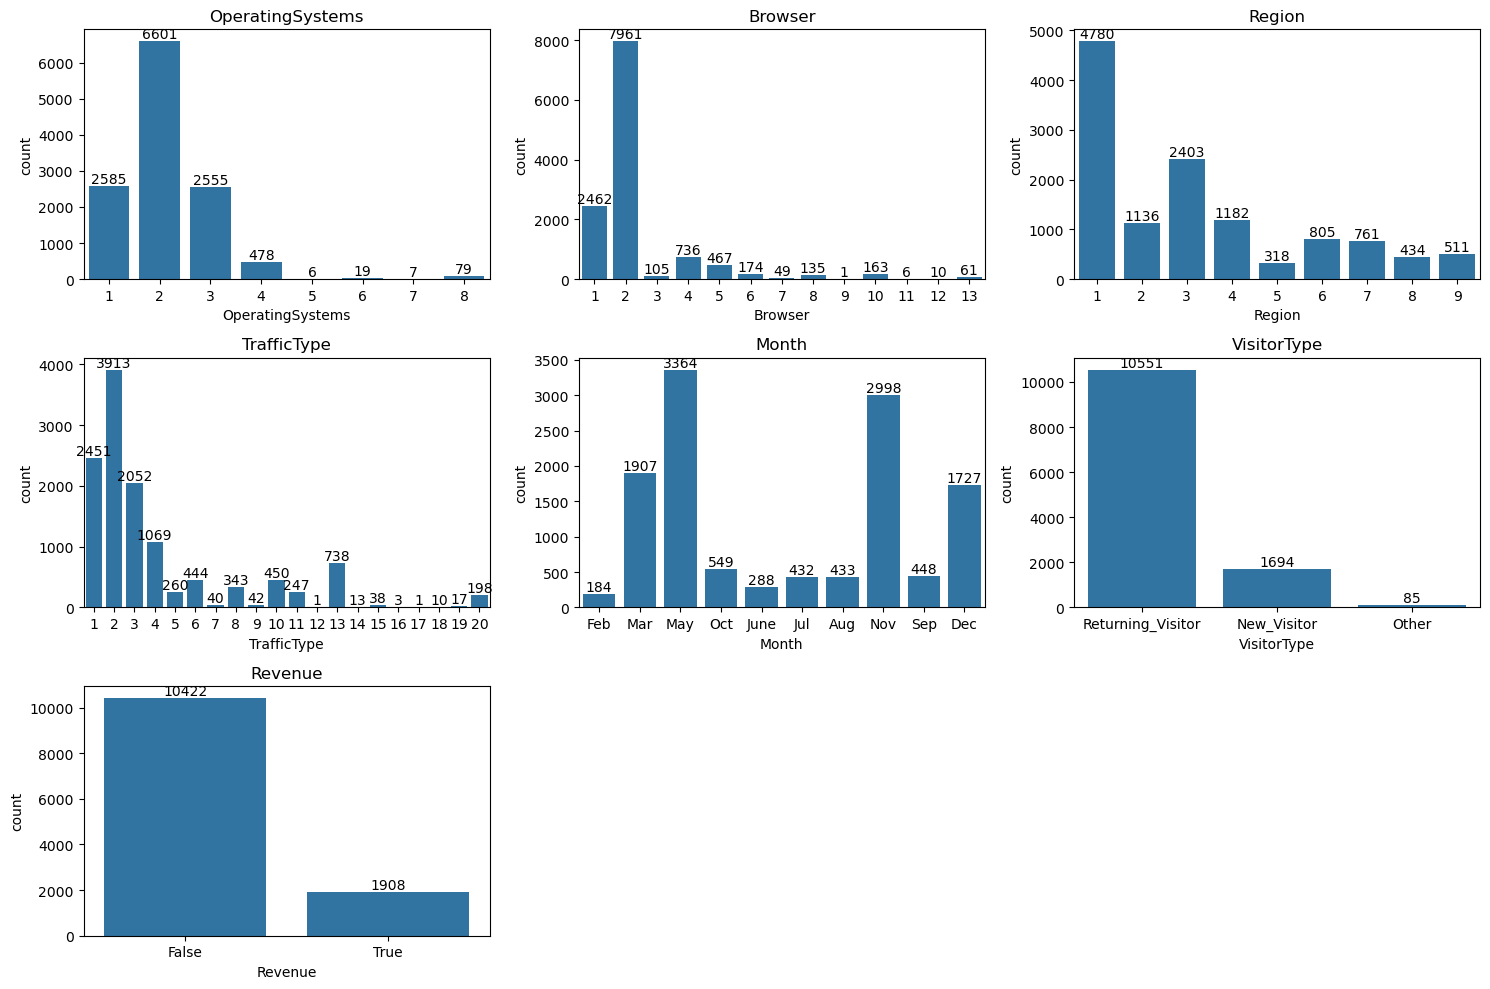

In [11]:
# Categorical Feature Frequency

cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Month', 'VisitorType', "Revenue"]

fig, axes = plt.subplots(nrows = 3, ncols=3, figsize = (15,10))
axes = axes.flatten()
for i, col in enumerate(cols):
    ax = sns.countplot(data = df, x = col, ax = axes[i])
    ax.bar_label(ax.containers[0])
    ax.set_title(col)
# Hide the extra empty subplots
for j in range(len(cols), len(axes)):
    axes[j].set_axis_off()
plt.tight_layout()
plt.show()

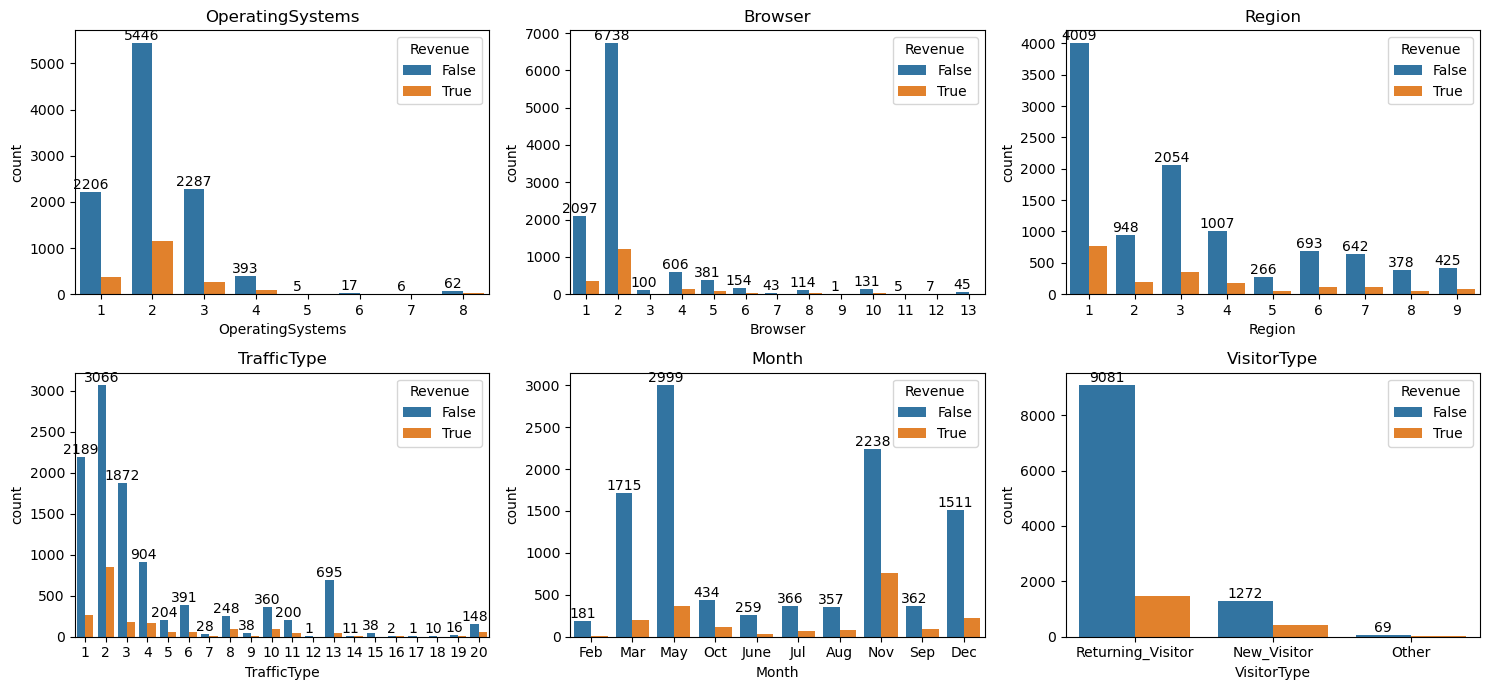

In [12]:
# Category Analysis by Revenue

cols = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Month', 'VisitorType']

fig, axes = plt.subplots(nrows = 2, ncols=3, figsize = (15,7))
axes = axes.flatten()
for i, col in enumerate(cols):
    ax = sns.countplot(data = df, x = col, hue = "Revenue", ax = axes[i])
    ax.bar_label(ax.containers[0])
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [13]:
col_num

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType'],
      dtype='object')

In [14]:
cols = ['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']



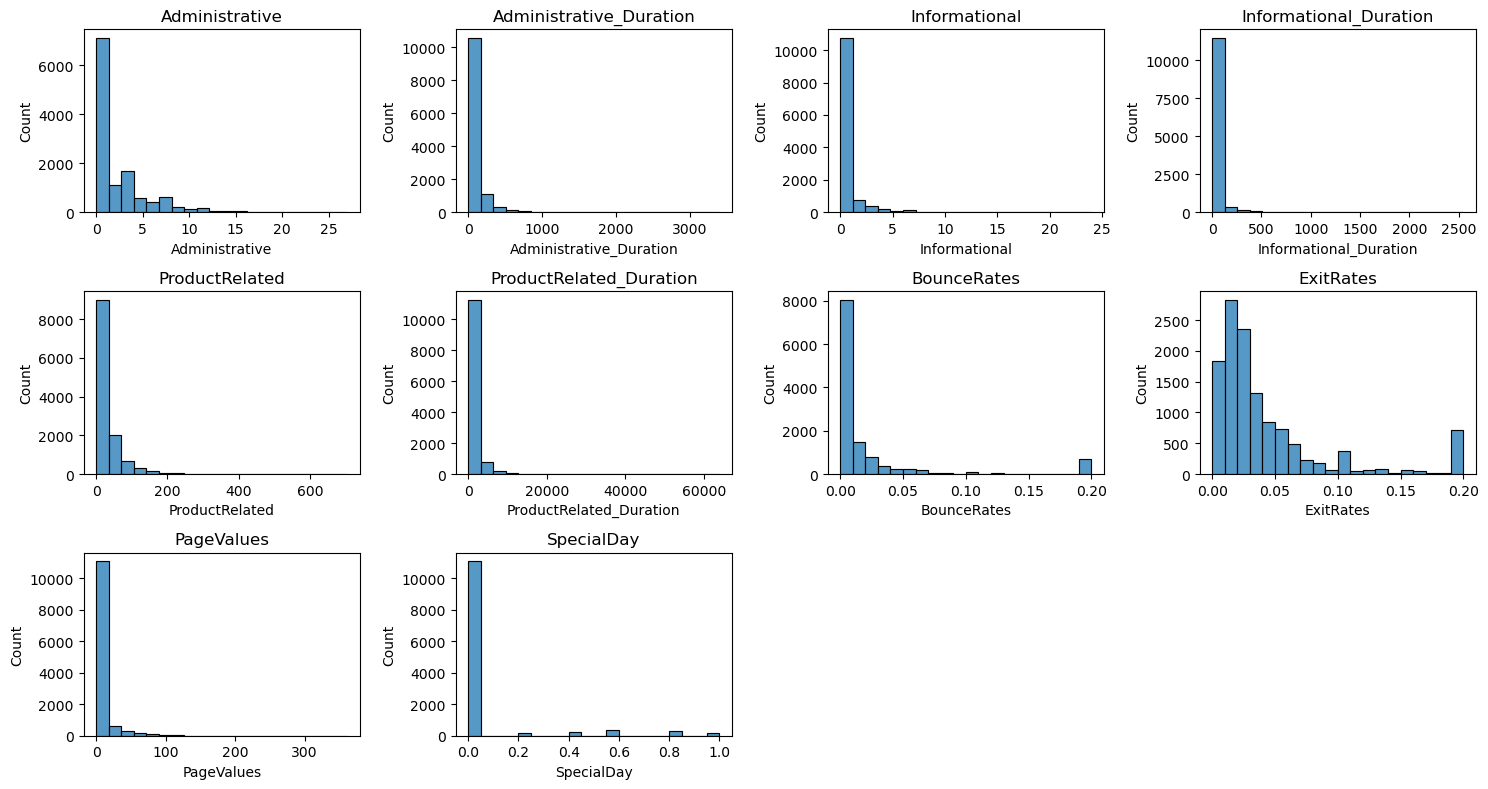

In [15]:
# # Numerical Data Distribution

cols = ['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
fig, axes = plt.subplots(nrows=3, ncols=4, figsize = (15,8))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.histplot(data = df, x = col,bins = 20, ax= axes[i])
    ax.set_title(col)
    
# # Hide the extra empty subplots
for j in range(len(cols), len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()

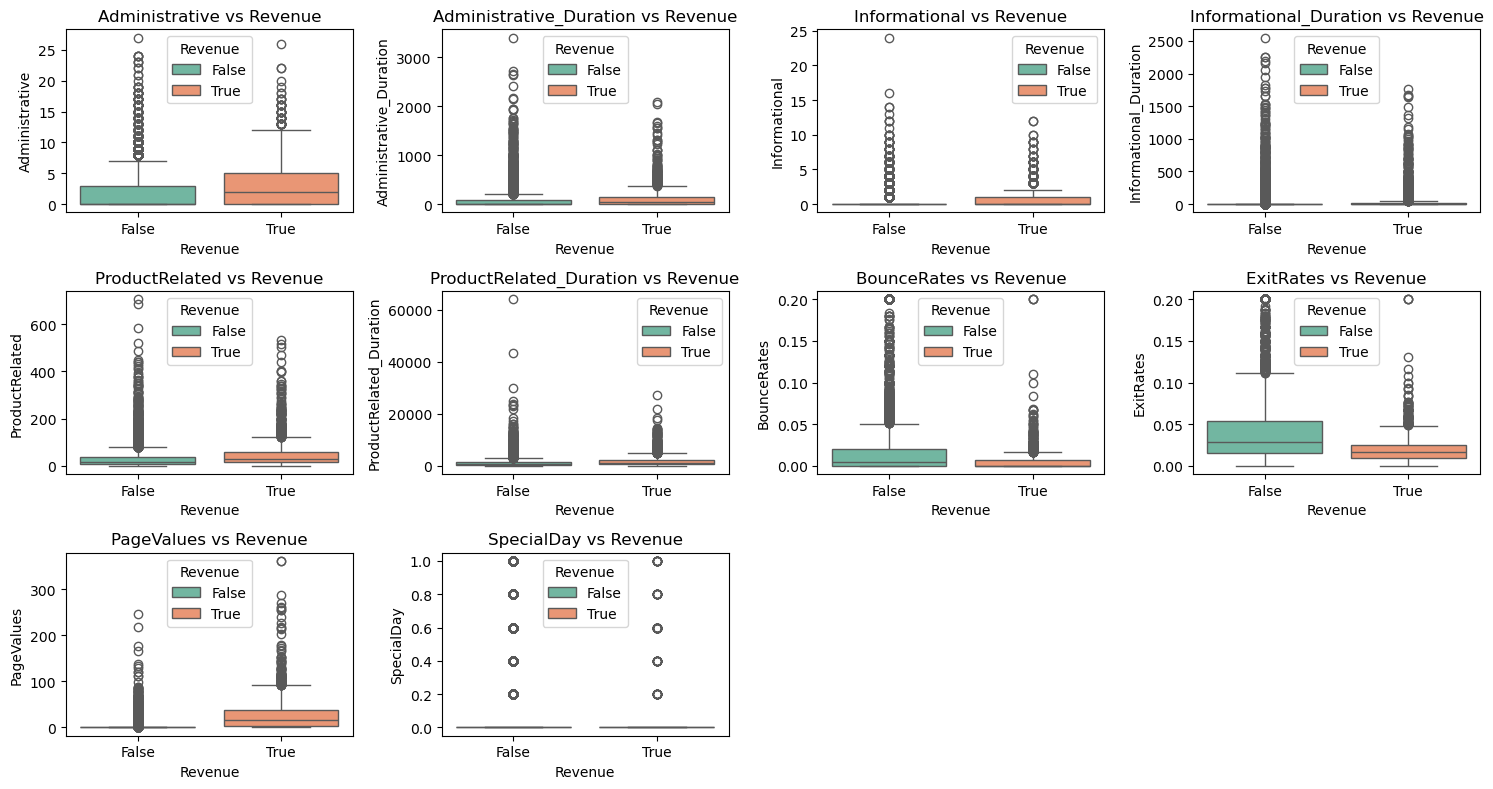

In [16]:
# Outlier Detection via Boxplots

cols = ['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
fig, axes = plt.subplots(nrows=3, ncols=4, figsize = (15,8))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.boxplot(data = df, x = "Revenue", y = col, hue = "Revenue", ax= axes[i], palette='Set2')
    axes[i].set_title(f"{col} vs Revenue")
    axes[i].set_xlabel("Revenue")
    axes[i].set_ylabel(col)
    
# # Hide the extra empty subplots
for j in range(len(cols), len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()

## Encoding

In [17]:
col_cat

Index(['Month', 'VisitorType'], dtype='object')

In [18]:
# bool_types
df["Revenue"] = df["Revenue"].astype(int)
df["Weekend"] = df["Weekend"].astype(int)

In [19]:
month_map = {
    "Jan":1, "Feb":2, "Mar":3, "Apr":4,
    "May":5, "June":6, "Jul":7, "Aug":8,
    "Sep":9, "Oct":10, "Nov":11, "Dec":12
}

df["Month"] = df["Month"].map(month_map)

In [20]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
ohe = OneHotEncoder(drop = "first", sparse_output=False, handle_unknown='ignore')
ohe_encoded = ohe.fit_transform(df[["VisitorType"]])
encoded_df = pd.DataFrame(ohe_encoded,  columns = ohe.get_feature_names_out(["VisitorType"]), index=df.index)
df = pd.concat([df.drop(columns = ["VisitorType"]),encoded_df], axis = 1)

In [21]:
df.head(3)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,2,1,1,1,1,0,0,0.0,1.0
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,2,2,2,1,2,0,0,0.0,1.0
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,2,4,1,9,3,0,0,0.0,1.0


## Train_test_split

In [22]:
X = df.drop("Revenue", axis =1)
y = df["Revenue"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [24]:
X_train

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,VisitorType_Other,VisitorType_Returning_Visitor
1785,0,0.000000,0,0.0,7,95.000000,0.014286,0.061905,0.000000,0.0,3,2,6,1,1,0,0.0,1.0
10407,2,14.000000,0,0.0,81,1441.910588,0.002469,0.013933,2.769599,0.0,11,2,2,3,2,0,0.0,1.0
286,0,0.000000,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,3,2,2,1,1,0,0.0,1.0
6520,5,49.200000,4,379.0,5,74.600000,0.000000,0.018182,8.326728,0.0,9,2,2,8,2,0,0.0,0.0
12251,0,0.000000,1,5.0,9,279.000000,0.040000,0.041667,0.000000,0.0,11,3,2,7,8,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11964,14,1005.608333,0,0.0,25,732.344872,0.000000,0.015676,0.000000,0.0,11,3,2,1,2,0,0.0,1.0
5191,0,0.000000,0,0.0,14,340.000000,0.000000,0.015385,23.388000,0.0,5,2,2,3,1,1,0.0,1.0
5390,0,0.000000,0,0.0,3,189.000000,0.000000,0.066667,0.000000,0.0,5,2,2,3,4,0,0.0,1.0
860,0,0.000000,0,0.0,13,305.000000,0.000000,0.016667,0.000000,0.0,3,1,1,1,2,0,0.0,0.0


## Pre_pruning model

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, f1_score, recall_score

max_depths = [2,4,6,8,10,12]
for depth in max_depths:
    demo_model = DecisionTreeClassifier(max_depth = depth)
    demo_model.fit(X_train, y_train)
    y_pred = demo_model.predict(X_test)
    print("For max depth:", depth," Accuracy Score: ", accuracy_score(y_test, y_pred), "and F1 score: ",
         f1_score(y_test, y_pred))

For max depth: 2  Accuracy Score:  0.8763179237631792 and F1 score:  0.5256609642301711
For max depth: 4  Accuracy Score:  0.8901054339010543 and F1 score:  0.6312925170068027
For max depth: 6  Accuracy Score:  0.8921330089213301 and F1 score:  0.6490765171503958
For max depth: 8  Accuracy Score:  0.8832116788321168 and F1 score:  0.616
For max depth: 10  Accuracy Score:  0.8824006488240065 and F1 score:  0.6164021164021164
For max depth: 12  Accuracy Score:  0.8751013787510138 and F1 score:  0.5968586387434555


In [26]:
min_samples_leafs = [5,10,15,20,25,30,35,40,45,50,55,60,65,70]
for leaf in min_samples_leafs:
    demo_model = DecisionTreeClassifier(max_depth = 8, min_samples_leaf = leaf)
    demo_model.fit(X_train, y_train)
    x_pred = demo_model.predict(X_train)
    y_pred = demo_model.predict(X_test)
    print("Train data: For min_leaf", leaf," Accuracy Score: ", accuracy_score(y_train, x_pred), "and F1 Score: ",
         f1_score(y_train, x_pred))
    print("Test data: For min_leaf", leaf," Accuracy Score: ", accuracy_score(y_test, y_pred), "and F1 Score: ",
         f1_score(y_test, y_pred))

Train data: For min_leaf 5  Accuracy Score:  0.9272100567721006 and F1 Score:  0.7332838038632986
Test data: For min_leaf 5  Accuracy Score:  0.8864557988645579 and F1 Score:  0.6195652173913043
Train data: For min_leaf 10  Accuracy Score:  0.9233576642335767 and F1 Score:  0.71875
Test data: For min_leaf 10  Accuracy Score:  0.8909164639091647 and F1 Score:  0.627939142461964
Train data: For min_leaf 15  Accuracy Score:  0.920316301703163 and F1 Score:  0.7071535022354695
Test data: For min_leaf 15  Accuracy Score:  0.8913219789132197 and F1 Score:  0.6256983240223464
Train data: For min_leaf 20  Accuracy Score:  0.9181873479318735 and F1 Score:  0.6969583176868194
Test data: For min_leaf 20  Accuracy Score:  0.8876723438767234 and F1 Score:  0.6104078762306611
Train data: For min_leaf 25  Accuracy Score:  0.9175790754257908 and F1 Score:  0.6905215074229158
Test data: For min_leaf 25  Accuracy Score:  0.8913219789132197 and F1 Score:  0.6225352112676056
Train data: For min_leaf 30  A

# best model is
1. Train data: For min_leaf 50 and depth 8 Accuracy Score:  0.9119018653690186 and F1 Score:  0.689975026757046
2.  Test data: For min_leaf 50 and depth 8 Accuracy Score:  0.8965936739659367 and F1 Score:  0.6613545816733067

In [27]:
model = DecisionTreeClassifier(max_depth = 8, min_samples_leaf = 50)
model.fit(X_train, y_train)
x_pred = model.predict(X_train)
y_pred = model.predict(X_test)

print("For train data:", "\nAccuracy score: ", accuracy_score(y_train, x_pred),
     "\nF1 score: ", f1_score(y_train, x_pred))
print("For test data:", "\nAccuracy score: ", accuracy_score(y_test, y_pred),
     "\nF1 score: ", f1_score(y_test, y_pred))

For train data: 
Accuracy score:  0.9119018653690186 
F1 score:  0.689975026757046
For test data: 
Accuracy score:  0.8965936739659367 
F1 score:  0.6613545816733067


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

model = DecisionTreeClassifier(max_depth = 8, min_samples_leaf = 50, )
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

F1 score: 0.6613545816733067

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94      2055
           1       0.73      0.61      0.66       411

    accuracy                           0.90      2466
   macro avg       0.83      0.78      0.80      2466
weighted avg       0.89      0.90      0.89      2466


Confusion Matrix:
 [[1962   93]
 [ 162  249]]


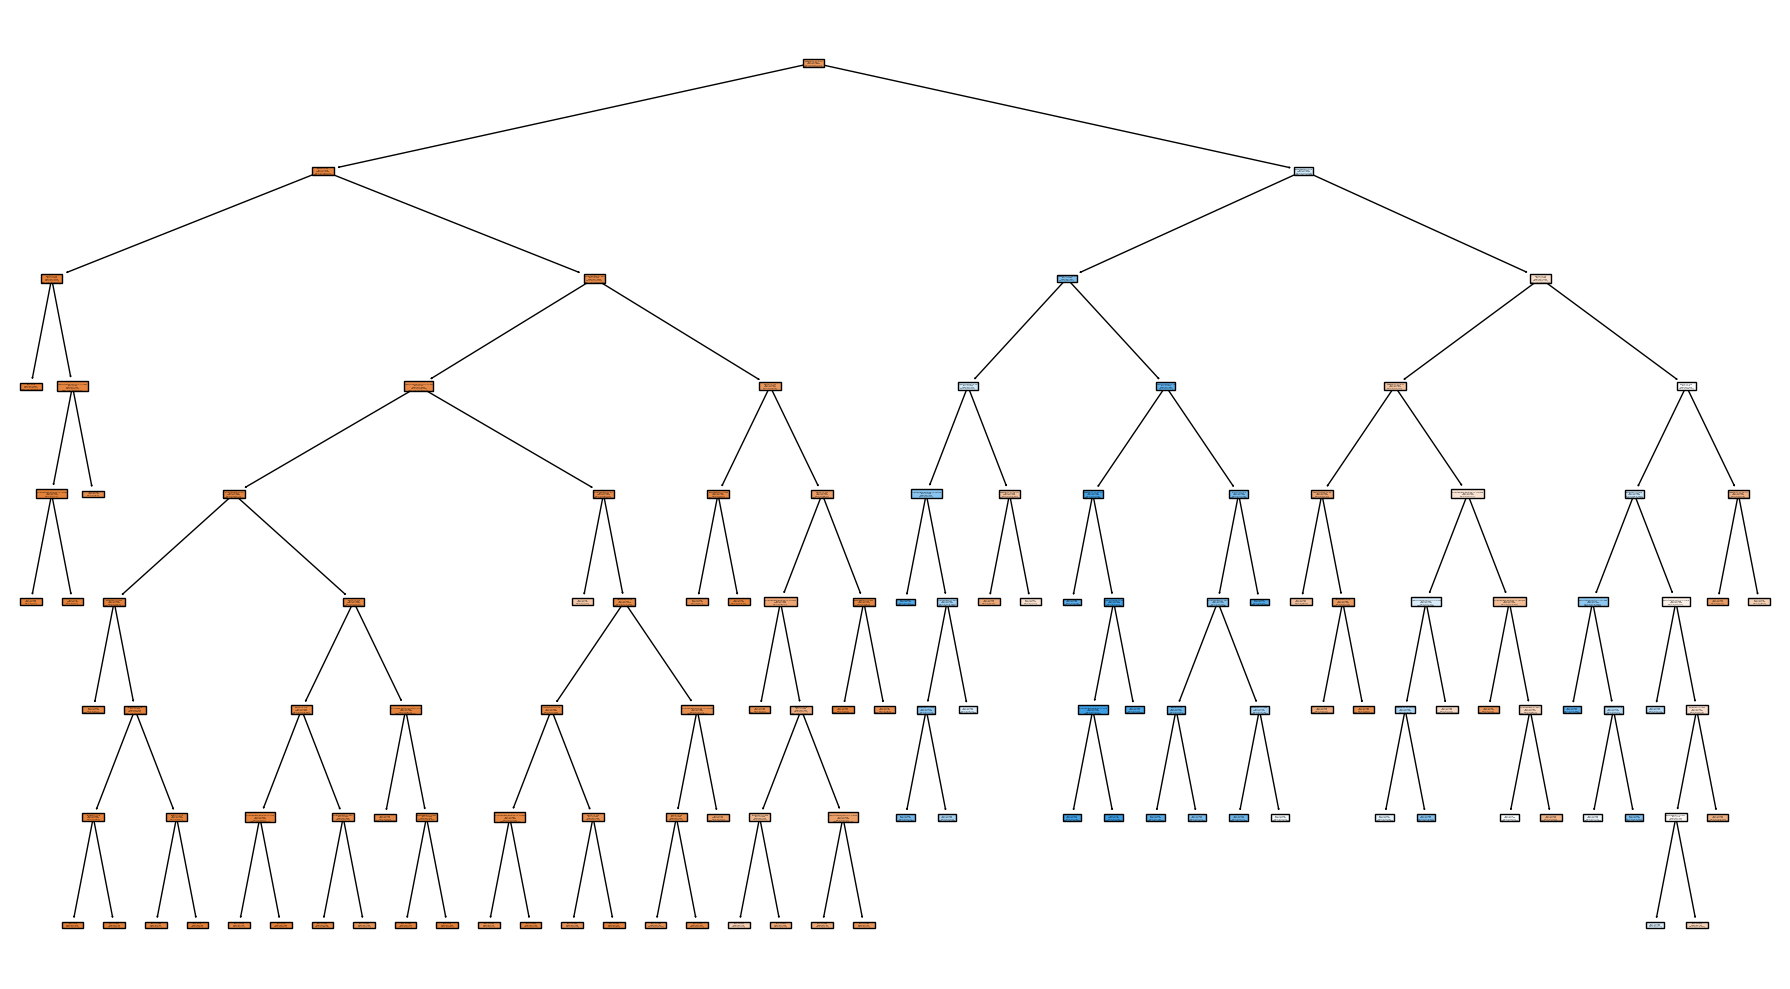

In [29]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth = 8, min_samples_leaf = 50, )
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.tree import plot_tree
plt.figure(figsize = (18,10))
plot_tree(model,
    feature_names = X.columns,
    class_names = ["Will Not Purchase", "Will Parchase"],
    filled = True
)
plt.tight_layout()
plt.show()